(150, 5)
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
Species              category
dtype: object
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min      

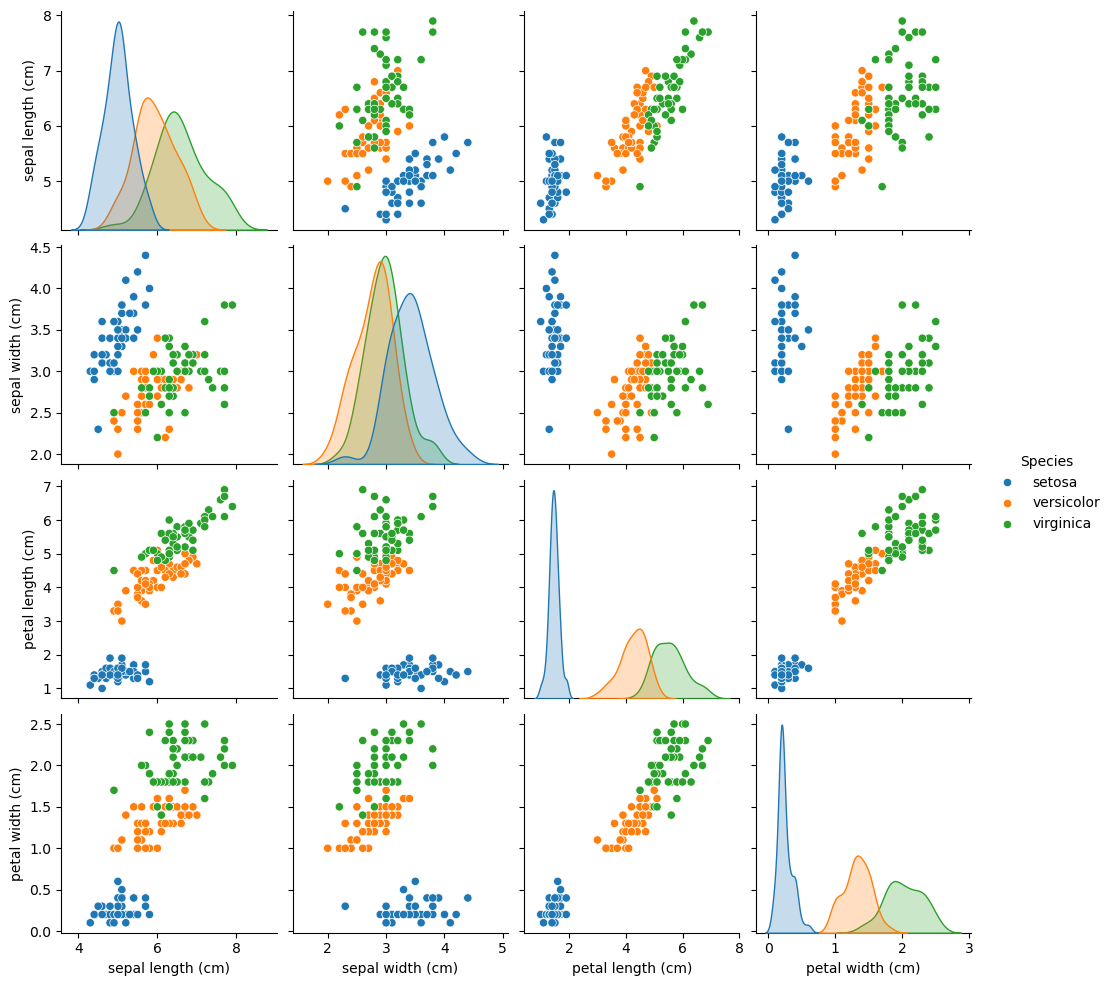

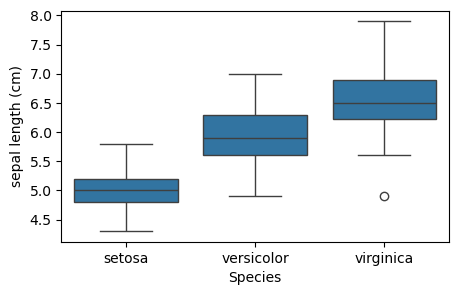

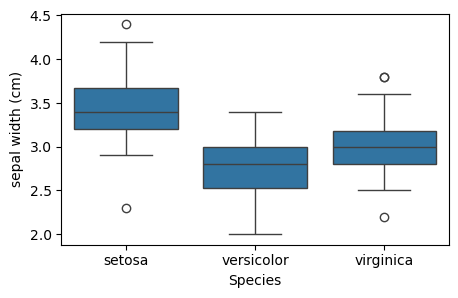

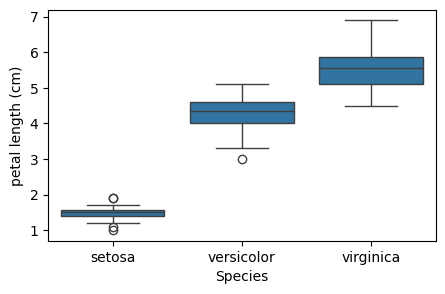

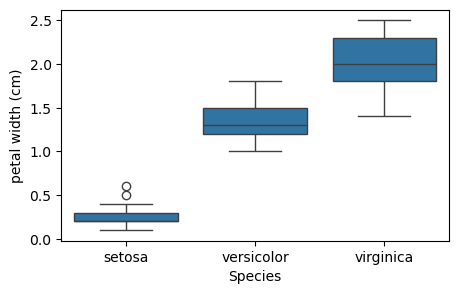


 Logistic Regression
Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


 Random Forest
Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Best Model: Logistic Regression Accuracy: 1.0


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['Species']=pd.Categorical.from_codes(iris.target, iris.target_names)

# EDA
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

# Pairplot
sns.pairplot(df,hue='Species')
plt.show()

# Boxplots
for c in df.columns[:-1]:
    plt.figure(figsize=(5,3))
    sns.boxplot(data=df,x='Species',y=c)
    plt.show()

# Feature selection:
# Petal length and petal width are the most discriminative features.

X=df.iloc[:,:-1]
y=iris.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

models={
'Logistic Regression':LogisticRegression(max_iter=200),
'Random Forest':RandomForestClassifier(random_state=42)
}
best=None
best_acc=0
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    print("\n",name)
    print("Accuracy:",acc)
    print(confusion_matrix(y_test,pred))
    print(classification_report(y_test,pred))
    if acc>best_acc:
        best_acc=acc
        best=name
print("Best Model:",best,"Accuracy:",best_acc)
